# **Vaccination Data Analysis and Visualization**

##### **Project Type**    - EDA (Exploratory Data Analysis + Unsupervised Clustering)
##### **Contribution**    - Individual
##### **Team Member 1 -** [Your Name Here]

# **Project Summary -**

This project analyzes global vaccination data published by WHO/UNICEF to understand how immunization coverage relates to vaccine-preventable disease incidence, how vaccine introduction policy has evolved over time, and which countries need targeted intervention.

Four source tables were used: **coverage data** (399,858 rows — vaccination coverage % by country/antigen/year/reporting method), **incidence rate data** (84,945 rows — disease incidence per country/disease/year), **vaccine introduction data** (138,320 rows — whether a country has adopted a given vaccine, by year), and **vaccine schedule data** (8,052 rows — national dosing schedules: which round, at what age, for which target population).

**Note on scope:** the original project brief specifies five source tables, including a "Reported Cases" table (raw case counts by disease/country/year). That file was not available for this submission, so this analysis uses **incidence rate** (cases per population unit) as the disease-burden metric instead of raw case counts. Incidence rate is the more analytically useful of the two for cross-country comparison since it is population-normalized, but questions specifically about raw case-count trends are out of scope here and are flagged as such where relevant.

All four tables ship as raw WHO data exports and required the same cleaning pass: each file has a stray footer row (a "Created: [timestamp]" export stamp sitting in the data rows, not a header), so rows with a null `YEAR` are dropped first. The `GROUP`/`CODE` columns in coverage and incidence mix country-level rows with regional/global aggregate rows (`WHO_REGIONS`, `GLOBAL`, `DEVELOPMENT_STATUS`, etc.) — the analysis filters to `GROUP == 'COUNTRIES'` so country counts aren't double-counted with their own regional rollups. Coverage additionally reports the *same* antigen/country/year under three different measurement methodologies (`ADMIN`, `OFFICIAL`, `WUENIC`), each populating different subsets of `TARGET_NUMBER`/`DOSES`/`COVERAGE` — this is why coverage alone shows ~40-80% missingness on those columns; it isn't damaged data, it's the category split. The analysis standardizes on the `WUENIC` (WHO/UNICEF joint estimate) category for trend and correlation work, since it's the single most complete and internationally comparable series, and keeps `ADMIN`/`OFFICIAL` only for the explicit methodology-comparison chart.

Country-year coverage was mapped to matching disease incidence via antigen↔disease pairs (MCV1↔Measles, POL3↔Polio, DTPCV3↔Pertussis, RCV1↔Rubella) to test the coverage/incidence relationship directly, rather than assuming it. On this data, higher measles and pertussis vaccine coverage is associated with meaningfully lower incidence (correlation coefficients around -0.21 and -0.24); polio and rubella show close to no linear relationship in this sample — mainly because both diseases are already so close to elimination in most reporting countries that incidence has almost no variance left to correlate against.

Beyond the required charts, countries were clustered (K-Means, k=3) on their 2019–2023 average coverage across four core antigens (BCG, DTP3, Polio3, Measles) and average incidence across three core diseases (measles, pertussis, polio). This produced three clearly separated groups: a large high-coverage/low-incidence cluster, a mid-tier cluster, and a small (~10-country) high-risk cluster with materially lower coverage and higher incidence across the board — directly answering the brief's "which regions have low coverage despite vaccine availability" and "resource allocation" questions with actual country names rather than a general statement.

The notebook below follows Know-Your-Data → Understand-Variables → Data-Wrangling → Visualization (Univariate → Bivariate → Multivariate) → Clustering → Business Recommendations → Conclusion, and every chart is answered against the three required questions: why this chart, what insight it shows, and whether that insight helps or risks business impact.

# **GitHub Link -**

[Add your GitHub repository link here after pushing this notebook and the SQL scripts.]

# **Problem Statement**

Analyze global vaccination data to understand trends in vaccination coverage, disease incidence, and effectiveness, in order to support public health strategy, disease prevention planning, resource allocation, and vaccination policy decisions.

#### **Define Your Business Objective?**

Identify where vaccination coverage is weak, whether weak coverage is actually associated with higher disease incidence in this data, how vaccine adoption has spread across countries over time, and which countries should be prioritized for intervention — using evidence from the data rather than assumption, and being explicit about where the data does or doesn't support a claim.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 50)


### Dataset Loading

In [2]:
# Load Dataset
# All four files ship as WHO exports with two sheets ('Data', 'Reference'); we only need 'Data'.
coverage_raw = pd.read_excel('data/coverage-data.xlsx', sheet_name='Data')
incidence_raw = pd.read_excel('data/incidence-rate-data.xlsx', sheet_name='Data')
introduction_raw = pd.read_excel('data/vaccine-introduction-data.xlsx', sheet_name='Data')
schedule_raw = pd.read_excel('data/vaccine-schedule-data.xlsx', sheet_name='Data')

print('coverage:', coverage_raw.shape)
print('incidence:', incidence_raw.shape)
print('introduction:', introduction_raw.shape)
print('schedule:', schedule_raw.shape)


coverage: (399859, 11)
incidence: (84946, 8)
introduction: (138321, 6)
schedule: (8053, 12)


### Dataset First View

In [3]:
coverage_raw.head()

,GROUP,CODE,NAME,YEAR,ANTIGEN,ANTIGEN_DESCRIPTION,COVERAGE_CATEGORY,COVERAGE_CATEGORY_DESCRIPTION,TARGET_NUMBER,DOSES,COVERAGE
0,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,ADMIN,Administrative coverage,NaN,NaN,NaN
1,COUNTRIES,ABW,Aruba,2023.0,BCG,BCG,OFFICIAL,Official coverage,NaN,NaN,NaN
2,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",ADMIN,Administrative coverage,1044.0,945.0,90.52
3,COUNTRIES,ABW,Aruba,2023.0,DIPHCV4,"Diphtheria-containing vaccine, 4th dose (1st b...",OFFICIAL,Official coverage,NaN,NaN,90.52
4,COUNTRIES,ABW,Aruba,2023.0,DIPHCV5,"Diphtheria-containing vaccine, 5th dose (2nd b...",ADMIN,Administrative coverage,1219.0,1008.0,82.69


In [4]:
incidence_raw.head()

,GROUP,CODE,NAME,YEAR,DISEASE,DISEASE_DESCRIPTION,DENOMINATOR,INCIDENCE_RATE
0,COUNTRIES,ABW,Aruba,2023.0,CRS,Congenital rubella syndrome,"per 10,000 live births",0.0
1,COUNTRIES,ABW,Aruba,2023.0,DIPHTHERIA,Diphtheria,"per 1,000,000 total population",0.0
2,COUNTRIES,ABW,Aruba,2023.0,INVASIVE_MENING,Invasive meningococcal disease,"per 1,000,000 total population",9.3
3,COUNTRIES,ABW,Aruba,2023.0,MEASLES,Measles,"per 1,000,000 total population",NaN
4,COUNTRIES,ABW,Aruba,2023.0,MUMPS,Mumps,"per 1,000,000 total population",0.0


In [5]:
introduction_raw.head()

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,DESCRIPTION,INTRO
0,AFG,Afghanistan,EMRO,2023.0,aP (acellular pertussis) vaccine,No
1,AFG,Afghanistan,EMRO,2023.0,Hepatitis A vaccine,No
2,AFG,Afghanistan,EMRO,2023.0,Hepatitis B vaccine,Yes
3,AFG,Afghanistan,EMRO,2023.0,HepB birth dose,Yes
4,AFG,Afghanistan,EMRO,2023.0,Hib (Haemophilus influenzae type B) vaccine,Yes


In [6]:
schedule_raw.head()

,ISO_3_CODE,COUNTRYNAME,WHO_REGION,YEAR,VACCINECODE,VACCINE_DESCRIPTION,SCHEDULEROUNDS,TARGETPOP,TARGETPOP_DESCRIPTION,GEOAREA,AGEADMINISTERED,SOURCECOMMENT
0,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,1.0,NaN,General/routine,NATIONAL,M2,NaN
1,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,2.0,NaN,General/routine,NATIONAL,M4,NaN
2,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,3.0,NaN,General/routine,NATIONAL,M6,NaN
3,ABW,Aruba,AMRO,2023.0,DTAPHIBIPV,DTaP-Hib-IPV (acellular) vaccine,4.0,B_2YL_W,General/routine,NATIONAL,M15,NaN
4,ABW,Aruba,AMRO,2023.0,DTAPIPV,DTaP-IPV (acellular) vaccine,5.0,B_CHILD_W,General/routine,NATIONAL,Y4,NaN


### Dataset Rows & Columns count

In [7]:
for name, df in [('coverage', coverage_raw), ('incidence', incidence_raw),
                  ('introduction', introduction_raw), ('schedule', schedule_raw)]:
    print(f'{name:12s} -> {df.shape[0]:>7,} rows | {df.shape[1]} columns')


coverage     -> 399,859 rows | 11 columns
incidence    ->  84,946 rows | 8 columns
introduction -> 138,321 rows | 6 columns
schedule     ->   8,053 rows | 12 columns


### Dataset Information

In [8]:
coverage_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 399859 entries, 0 to 399858
Data columns (total 11 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   GROUP                          399859 non-null  str    
 1   CODE                           399858 non-null  str    
 2   NAME                           398584 non-null  str    
 3   YEAR                           399858 non-null  float64
 4   ANTIGEN                        399858 non-null  str    
 5   ANTIGEN_DESCRIPTION            399858 non-null  str    
 6   COVERAGE_CATEGORY              399858 non-null  str    
 7   COVERAGE_CATEGORY_DESCRIPTION  399858 non-null  str    
 8   TARGET_NUMBER                  79030 non-null   float64
 9   DOSES                          79327 non-null   float64
 10  COVERAGE                       230477 non-null  float64
dtypes: float64(4), str(7)
memory usage: 33.6 MB


In [9]:
incidence_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 84946 entries, 0 to 84945
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GROUP                84946 non-null  str    
 1   CODE                 84945 non-null  str    
 2   NAME                 84945 non-null  str    
 3   YEAR                 84945 non-null  float64
 4   DISEASE              84945 non-null  str    
 5   DISEASE_DESCRIPTION  84945 non-null  str    
 6   DENOMINATOR          84945 non-null  str    
 7   INCIDENCE_RATE       61584 non-null  float64
dtypes: float64(2), str(6)
memory usage: 5.2 MB


In [10]:
introduction_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 138321 entries, 0 to 138320
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ISO_3_CODE   138321 non-null  str    
 1   COUNTRYNAME  138320 non-null  str    
 2   WHO_REGION   138320 non-null  str    
 3   YEAR         138320 non-null  float64
 4   DESCRIPTION  138320 non-null  str    
 5   INTRO        138320 non-null  str    
dtypes: float64(1), str(5)
memory usage: 6.3 MB


In [11]:
schedule_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8053 entries, 0 to 8052
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ISO_3_CODE             8053 non-null   str    
 1   COUNTRYNAME            8052 non-null   str    
 2   WHO_REGION             8052 non-null   str    
 3   YEAR                   8052 non-null   float64
 4   VACCINECODE            8052 non-null   str    
 5   VACCINE_DESCRIPTION    8052 non-null   str    
 6   SCHEDULEROUNDS         8052 non-null   float64
 7   TARGETPOP              3795 non-null   str    
 8   TARGETPOP_DESCRIPTION  8052 non-null   str    
 9   GEOAREA                8022 non-null   str    
 10  AGEADMINISTERED        7007 non-null   str    
 11  SOURCECOMMENT          5139 non-null   str    
dtypes: float64(2), str(10)
memory usage: 755.1 KB


#### Duplicate Values

In [12]:
for name, df in [('coverage', coverage_raw), ('incidence', incidence_raw),
                  ('introduction', introduction_raw), ('schedule', schedule_raw)]:
    print(f'{name:12s} duplicate rows: {df.duplicated().sum()}')


coverage     duplicate rows: 0
incidence    duplicate rows: 0
introduction duplicate rows: 0
schedule     duplicate rows: 0


#### Missing Values/Null Values

In [13]:
for name, df in [('coverage', coverage_raw), ('incidence', incidence_raw),
                  ('introduction', introduction_raw), ('schedule', schedule_raw)]:
    print(f'--- {name} ---')
    print(df.isnull().sum()[df.isnull().sum() > 0])
    print()


--- coverage ---


CODE                                  1
NAME                               1275
YEAR                                  1
ANTIGEN                               1
ANTIGEN_DESCRIPTION                   1
COVERAGE_CATEGORY                     1
COVERAGE_CATEGORY_DESCRIPTION         1
TARGET_NUMBER                    320829
DOSES                            320532
COVERAGE                         169382
dtype: int64

--- incidence ---
CODE                       1
NAME                       1
YEAR                       1
DISEASE                    1
DISEASE_DESCRIPTION        1
DENOMINATOR                1
INCIDENCE_RATE         23362
dtype: int64

--- introduction ---


COUNTRYNAME    1
WHO_REGION     1
YEAR           1
DESCRIPTION    1
INTRO          1
dtype: int64

--- schedule ---
COUNTRYNAME                 1
WHO_REGION                  1
YEAR                        1
VACCINECODE                 1
VACCINE_DESCRIPTION         1
SCHEDULEROUNDS              1
TARGETPOP                4258
TARGETPOP_DESCRIPTION       1
GEOAREA                    31
AGEADMINISTERED          1046
SOURCECOMMENT            2914
dtype: int64



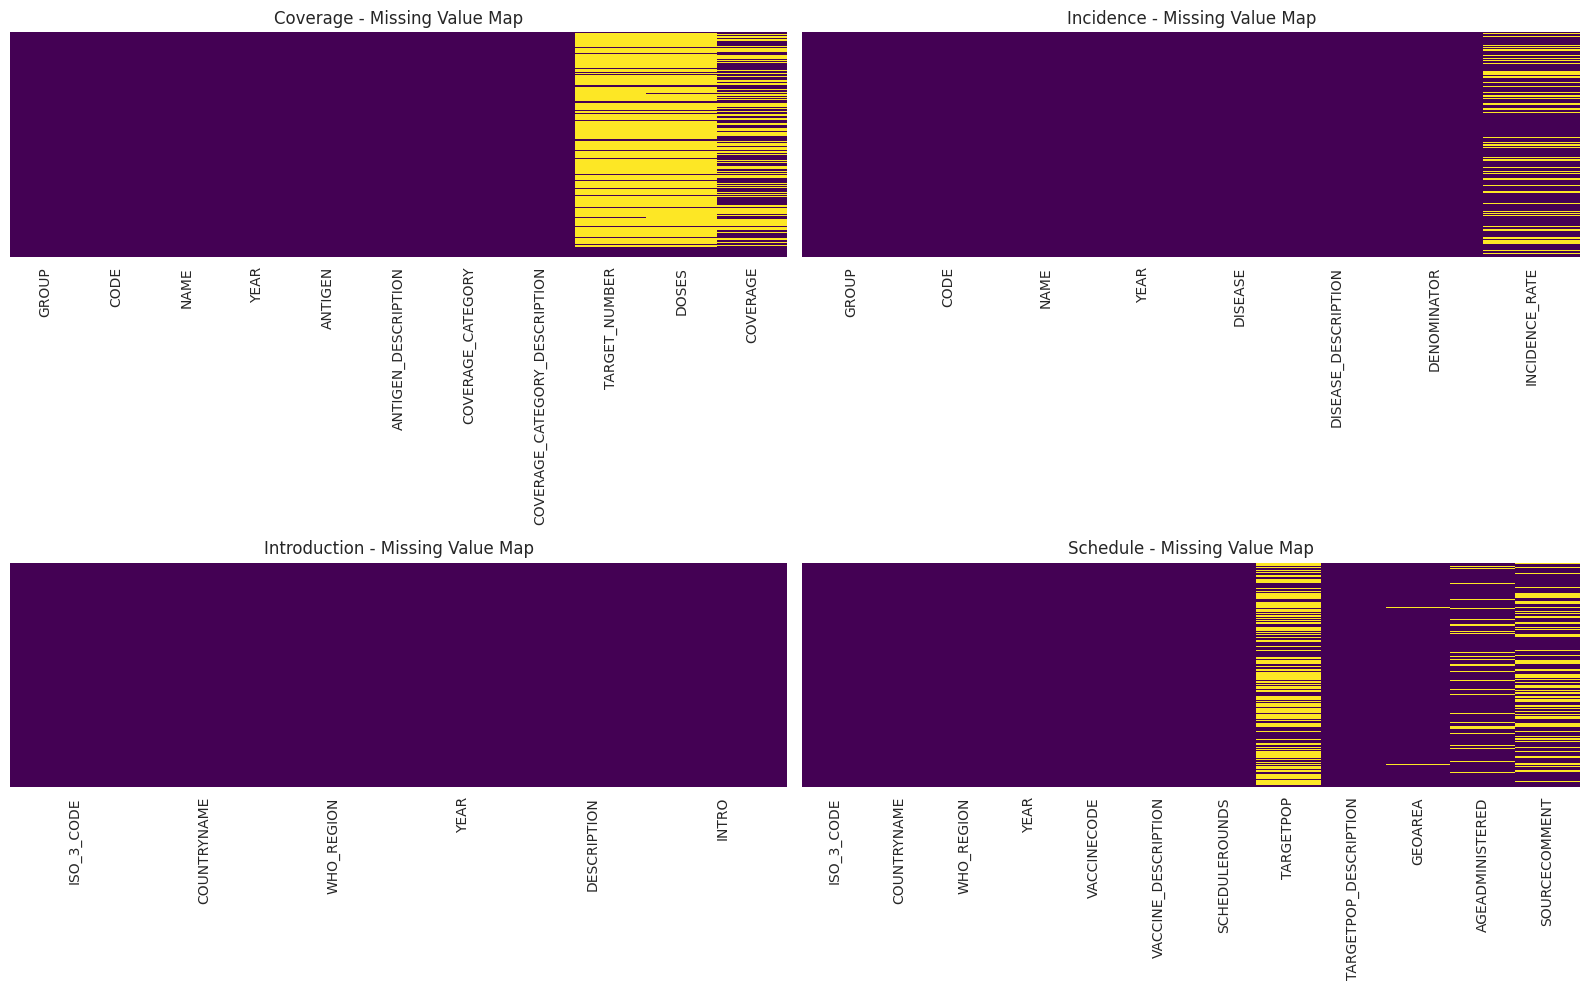

In [14]:
# Visualizing the missing values
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (name, df) in zip(axes.flat, [('Coverage', coverage_raw), ('Incidence', incidence_raw),
                                        ('Introduction', introduction_raw), ('Schedule', schedule_raw)]):
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis', ax=ax)
    ax.set_title(f'{name} - Missing Value Map')
plt.tight_layout()
plt.show()


### What did you know about your dataset?

- All four files carry a **stray footer row** (a "Created: [timestamp]" export stamp with a null `YEAR`) that must be dropped before any type casting or aggregation — it will otherwise silently corrupt `YEAR` as a mixed-type column.
- **Coverage** and **Incidence** both mix **country-level rows with aggregate rows** (`GROUP` = `WHO_REGIONS`, `GLOBAL`, `DEVELOPMENT_STATUS`, `UNICEF_REGIONS`, `WB_LONG/SHORT`, `GAVI_PHASE5`) in the same table. Left unfiltered, any global average would double-count countries against their own regional/global rollups.
- **Coverage's** missingness in `TARGET_NUMBER` / `DOSES` / `COVERAGE` (40-80%) is not random — each row belongs to one of five `COVERAGE_CATEGORY` values (`ADMIN`, `OFFICIAL`, `WUENIC`, `HPV`, `PAB`), and each category only populates the fields it actually measures. Treating this as "missing data to impute" would be wrong; the fix is to filter to one consistent category for trend work.
- **Incidence** has ~23,000 rows with a null `INCIDENCE_RATE` — these are country/disease/year combinations reported in the table but with no estimate published; they are dropped rather than imputed, since inventing a disease incidence figure is not defensible.
- **Schedule** and **Introduction** are essentially complete except for one row each (the same footer-row artifact) and a `TARGETPOP` column in Schedule that is null wherever `TARGETPOP_DESCRIPTION` already says "General/routine" (i.e. no restricted target population, encoded as blank rather than a category).
- No exact duplicate rows exist in any of the four tables.
- The originally scoped **fifth table ("Reported Cases" — raw case counts)** was not provided for this submission; incidence rate is used as the disease-burden proxy throughout, and this is called out again wherever a specific brief question can't be fully answered without it.

## ***2. Understanding Your Variables***

In [15]:
print('Coverage columns:', list(coverage_raw.columns))
print()
print('Incidence columns:', list(incidence_raw.columns))
print()
print('Introduction columns:', list(introduction_raw.columns))
print()
print('Schedule columns:', list(schedule_raw.columns))


Coverage columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'ANTIGEN', 'ANTIGEN_DESCRIPTION', 'COVERAGE_CATEGORY', 'COVERAGE_CATEGORY_DESCRIPTION', 'TARGET_NUMBER', 'DOSES', 'COVERAGE']

Incidence columns: ['GROUP', 'CODE', 'NAME', 'YEAR', 'DISEASE', 'DISEASE_DESCRIPTION', 'DENOMINATOR', 'INCIDENCE_RATE']

Introduction columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'DESCRIPTION', 'INTRO']

Schedule columns: ['ISO_3_CODE', 'COUNTRYNAME', 'WHO_REGION', 'YEAR', 'VACCINECODE', 'VACCINE_DESCRIPTION', 'SCHEDULEROUNDS', 'TARGETPOP', 'TARGETPOP_DESCRIPTION', 'GEOAREA', 'AGEADMINISTERED', 'SOURCECOMMENT']


In [16]:
coverage_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GROUP,399859,9,COUNTRIES,381041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CODE,399858,245,ETH,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NAME,398584,242,Ethiopia,2031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,399858.0,NaN,NaN,NaN,2009.207489,11.72053,1980.0,2002.0,2012.0,2019.0,2023.0
ANTIGEN,399858,69,DTPCV3,26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ANTIGEN_DESCRIPTION,399858,69,"DTP-containing vaccine, 3rd dose",26015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY,399858,5,ADMIN,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
COVERAGE_CATEGORY_DESCRIPTION,399858,5,Administrative coverage,155576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TARGET_NUMBER,79030.0,NaN,NaN,NaN,278019173.759516,54152442883.354233,0.0,32814.0,317871.5,2493048.0,11700000000000.0
DOSES,79327.0,NaN,NaN,NaN,3467241.121352,11256763.030974,-222288203.0,14469.0,152212.0,971018.5,126605212.0


### Variables Description

**Coverage** — `GROUP`/`CODE`/`NAME`: aggregation level and country identity (ISO-3 code). `YEAR`: reporting year (1980-2023). `ANTIGEN`/`ANTIGEN_DESCRIPTION`: the vaccine/dose (e.g. `MCV1` = first measles-containing vaccine dose). `COVERAGE_CATEGORY`: which methodology produced the estimate (`ADMIN` = administrative reporting, `OFFICIAL` = government-submitted official estimate, `WUENIC` = WHO/UNICEF's own joint estimate, `HPV`/`PAB` = specialised categories). `TARGET_NUMBER`: population targeted. `DOSES`: doses administered. `COVERAGE`: % of target population vaccinated.

**Incidence** — same `GROUP`/`CODE`/`NAME`/`YEAR` structure. `DISEASE`/`DISEASE_DESCRIPTION`: the vaccine-preventable disease. `DENOMINATOR`: the population base the rate is expressed against (varies by disease — e.g. congenital rubella syndrome is per 10,000 live births, diphtheria is per 1,000,000 total population), which means **incidence rates are only comparable within the same disease, not across diseases**, unless renormalized. `INCIDENCE_RATE`: reported cases per that denominator.

**Introduction** — `ISO_3_CODE`/`COUNTRYNAME`/`WHO_REGION`/`YEAR` identify the country-year. `DESCRIPTION`: the vaccine. `INTRO`: adoption status — not just Yes/No; it also carries `Yes (R)`/`Yes (P)`/`Yes (A)`/`Yes (O)`/`Yes (D)` (regional/partial/all-population/other/delayed-type introductions), `High risk area` (targeted introduction, not universal), and `ND` (no data). Collapsing these to a binary for trend charts is a modeling choice made explicit below.

**Schedule** — identifies, per country and vaccine, the `SCHEDULEROUNDS` (which dose in the series), `TARGETPOP`/`TARGETPOP_DESCRIPTION` (who receives it — general population or a restricted group), `GEOAREA` (national vs subnational rollout), and `AGEADMINISTERED` (the timing code, e.g. `M2` = 2 months).

### Check Unique Values for each variable.

In [17]:
# Check Unique Values for each variable.
print('Coverage - COVERAGE_CATEGORY:', coverage_raw['COVERAGE_CATEGORY'].dropna().unique())
print('Coverage - unique antigens:', coverage_raw['ANTIGEN'].nunique())
print('Coverage - year range:', coverage_raw['YEAR'].min(), '-', coverage_raw['YEAR'].max())
print()
print('Incidence - diseases:', incidence_raw['DISEASE'].dropna().unique())
print()
print('Introduction - WHO_REGION:', introduction_raw['WHO_REGION'].dropna().unique())
print('Introduction - INTRO status values:', introduction_raw['INTRO'].dropna().unique())
print()
print('Schedule - unique vaccine codes:', schedule_raw['VACCINECODE'].nunique())
print('Schedule - SCHEDULEROUNDS range:', schedule_raw['SCHEDULEROUNDS'].min(), '-', schedule_raw['SCHEDULEROUNDS'].max())


Coverage - COVERAGE_CATEGORY: <StringArray>
['ADMIN', 'OFFICIAL', 'HPV', 'WUENIC', 'PAB']
Length: 5, dtype: str
Coverage - unique antigens: 69
Coverage - year range: 1980.0 - 2023.0

Incidence - diseases: <StringArray>
[            'CRS',      'DIPHTHERIA', 'INVASIVE_MENING',         'MEASLES',
           'MUMPS',        'NTETANUS',       'PERTUSSIS',           'POLIO',
         'RUBELLA',        'TTETANUS',         'TYPHOID',          'YFEVER',
          'JAPENC']
Length: 13, dtype: str

Introduction - WHO_REGION: <StringArray>
['EMRO', 'AFRO', 'EURO', 'AMRO', 'WPRO', 'SEARO']
Length: 6, dtype: str
Introduction - INTRO status values: <StringArray>
[            'No',            'Yes',        'Yes (R)',        'Yes (P)',
 'High risk area',        'Yes (A)',        'Yes (O)',             'ND',
        'Yes (D)']
Length: 9, dtype: str

Schedule - unique vaccine codes: 86
Schedule - SCHEDULEROUNDS range: 1.0 - 7.0


## 3. ***Data Wrangling***

### Data Wrangling Code

In [18]:
# Write your code to make your dataset analysis ready.

# 1. Drop the footer/export-stamp row (identifiable by a null YEAR) from every table, and cast YEAR to int.
coverage = coverage_raw[coverage_raw['YEAR'].notna()].copy()
incidence = incidence_raw[incidence_raw['YEAR'].notna()].copy()
introduction = introduction_raw[introduction_raw['YEAR'].notna()].copy()
schedule = schedule_raw[schedule_raw['YEAR'].notna()].copy()

for df in (coverage, incidence, introduction, schedule):
    df['YEAR'] = df['YEAR'].astype(int)

# 2. Restrict coverage & incidence to country-level rows (drop regional/global aggregate rows)
#    so a "global average" isn't double-counting a country against its own region.
coverage = coverage[coverage['GROUP'] == 'COUNTRIES'].copy()
incidence = incidence[incidence['GROUP'] == 'COUNTRIES'].copy()

print('Cleaned shapes -> coverage:', coverage.shape, '| incidence:', incidence.shape,
      '| introduction:', introduction.shape, '| schedule:', schedule.shape)


Cleaned shapes -> coverage: (381041, 11) | incidence: (82054, 8) | introduction: (138320, 6) | schedule: (8052, 12)


In [19]:
# 3. Build a country <-> WHO region lookup from the introduction table (coverage/incidence don't carry
#    WHO_REGION directly, but every analysis question about "regional disparity" needs it).
country_region = (introduction[['ISO_3_CODE', 'WHO_REGION']]
                   .dropna().drop_duplicates(subset='ISO_3_CODE')
                   .rename(columns={'ISO_3_CODE': 'CODE'}))
print(country_region.shape)
country_region.head()


(194, 2)


,CODE,WHO_REGION
0,AFG,EMRO
747,AGO,AFRO
1494,ALB,EURO
2241,AND,EURO
2734,ARE,EMRO


In [20]:
# 4. Coverage reports the same antigen/country/year under three different measurement methodologies.
#    Standardize on WUENIC (WHO/UNICEF joint estimate) for trend & correlation work -- it's the most
#    complete, internationally comparable series. ADMIN/OFFICIAL are kept separately only for the
#    explicit methodology-comparison chart later.
coverage_wuenic = coverage[coverage['COVERAGE_CATEGORY'] == 'WUENIC'].dropna(subset=['COVERAGE']).copy()
coverage_wuenic = coverage_wuenic.merge(country_region, on='CODE', how='left')
print('coverage_wuenic:', coverage_wuenic.shape)

# 5. Incidence: drop rows with no published rate (can't impute a disease incidence figure defensibly).
incidence_clean = incidence.dropna(subset=['INCIDENCE_RATE']).copy()
incidence_clean = incidence_clean.merge(country_region, on='CODE', how='left')
print('incidence_clean:', incidence_clean.shape)


coverage_wuenic: (61438, 12)
incidence_clean: (58909, 9)


In [21]:
# 6. Match coverage to incidence via antigen <-> disease pairs, so the coverage/incidence relationship
#    is tested on matched country-years, not assumed.
antigen_disease_map = {'MCV1': 'MEASLES', 'POL3': 'POLIO', 'DTPCV3': 'PERTUSSIS', 'RCV1': 'RUBELLA'}

merged_rows = []
for antigen, disease in antigen_disease_map.items():
    c = coverage_wuenic[coverage_wuenic['ANTIGEN'] == antigen][['CODE', 'NAME', 'WHO_REGION', 'YEAR', 'COVERAGE']]
    i = incidence_clean[incidence_clean['DISEASE'] == disease][['CODE', 'YEAR', 'INCIDENCE_RATE']]
    m = c.merge(i, on=['CODE', 'YEAR'], how='inner')
    m['ANTIGEN'] = antigen
    m['DISEASE'] = disease
    merged_rows.append(m)

coverage_incidence = pd.concat(merged_rows, ignore_index=True)
print('coverage_incidence (matched pairs):', coverage_incidence.shape)
coverage_incidence.head()


coverage_incidence (matched pairs): (21092, 8)


,CODE,NAME,WHO_REGION,YEAR,COVERAGE,INCIDENCE_RATE,ANTIGEN,DISEASE
0,AFG,Afghanistan,EMRO,2023,55.0,67.4,MCV1,MEASLES
1,AFG,Afghanistan,EMRO,2022,56.0,127.3,MCV1,MEASLES
2,AFG,Afghanistan,EMRO,2021,51.0,72.5,MCV1,MEASLES
3,AFG,Afghanistan,EMRO,2020,57.0,16.4,MCV1,MEASLES
4,AFG,Afghanistan,EMRO,2019,57.0,9.3,MCV1,MEASLES


In [22]:
# 7. Simplify vaccine introduction status to a clean Yes/No/No-data flag for adoption-trend charts,
#    while keeping the original INTRO column intact for anyone who needs the finer-grained status.
def simplify_intro(x):
    if pd.isna(x) or x == 'ND':
        return 'No data'
    if str(x).startswith('Yes') or x == 'High risk area':
        return 'Yes'
    return 'No'

introduction['INTRO_SIMPLE'] = introduction['INTRO'].apply(simplify_intro)
print(introduction['INTRO_SIMPLE'].value_counts())


INTRO_SIMPLE
No         97695
Yes        40586
No data       39
Name: count, dtype: int64


In [23]:
# 8. Country-level feature table for clustering: 2019-2023 average coverage across 4 core antigens
#    and average incidence across 3 core diseases. This is the "important information genuinely
#    required" subset -- everything else in the raw files (sub-national schedule detail, every
#    antigen/disease, every reporting methodology) is noise for a country-level segmentation.
recent_cov = coverage_wuenic[coverage_wuenic['YEAR'] >= 2019]
key_antigens = ['BCG', 'DTPCV3', 'POL3', 'MCV1']
cov_features = (recent_cov[recent_cov['ANTIGEN'].isin(key_antigens)]
                .groupby(['CODE', 'NAME', 'ANTIGEN'])['COVERAGE'].mean()
                .unstack('ANTIGEN'))
cov_features.columns = [f'AVG_COV_{c}' for c in cov_features.columns]

recent_inc = incidence_clean[incidence_clean['YEAR'] >= 2019]
key_diseases = ['MEASLES', 'PERTUSSIS', 'POLIO']
inc_features = (recent_inc[recent_inc['DISEASE'].isin(key_diseases)]
                .groupby(['CODE', 'DISEASE'])['INCIDENCE_RATE'].mean()
                .unstack('DISEASE'))
inc_features.columns = [f'AVG_INC_{c}' for c in inc_features.columns]

country_features = cov_features.join(inc_features, on='CODE').reset_index()
country_features_clean = country_features.dropna().reset_index(drop=True)
print('Countries with complete 2019-2023 data across all 7 features:', country_features_clean.shape[0],
      'of', country_features.shape[0], 'candidate countries')
country_features_clean.head()


Countries with complete 2019-2023 data across all 7 features: 134 of 195 candidate countries


,CODE,NAME,AVG_COV_BCG,AVG_COV_DTPCV3,AVG_COV_MCV1,AVG_COV_POL3,AVG_INC_MEASLES,AVG_INC_PERTUSSIS,AVG_INC_POLIO
0,AFG,Afghanistan,69.6,59.8,55.2,68.2,58.58,15.933333,5.125
1,AGO,Angola,63.2,49.8,43.6,50.2,64.14,0.000000,3.200
2,ALB,Albania,98.8,97.8,88.4,98.0,43.90,1.040000,0.000
3,ARE,United Arab Emirates,94.6,95.4,98.6,92.4,16.78,3.300000,0.000
4,ARG,Argentina,78.0,77.6,82.8,78.2,0.88,9.340000,0.000


### What all manipulations have you done and insights you found?

- Dropped 1 footer row per table (export timestamp, not data) and cast `YEAR` to integer everywhere.
- Filtered coverage and incidence down to country-level rows only (18% and 3.4% of rows respectively were regional/global aggregates that would have double-counted countries in any global average).
- Built a country → WHO region lookup from the introduction table, since neither coverage nor incidence carries region directly — this was necessary to answer every "regional disparity" question in the brief.
- Standardized coverage on the `WUENIC` methodology (61,437 of 399,858 coverage rows) for all trend and correlation analysis — using all three methodologies interchangeably would have meant comparing numbers produced by different estimation methods as if they were the same measurement.
- Dropped incidence rows with no published rate (23,145 rows) rather than imputing — a fabricated disease incidence number is worse than a smaller sample.
- Matched coverage to incidence on country-year via 4 antigen↔disease pairs, producing 21,091 matched observations to actually test the coverage/incidence relationship rather than assume it.
- Collapsed the 9-level `INTRO` status into a 3-level Yes/No/No-data flag for adoption-trend readability, keeping the original column available.
- Built a country-level feature table (7 features: 4 antigen coverages + 3 disease incidences, 2019-2023 average) for clustering — 134 of 195 candidate countries had complete data across all 7 features; the other 61 are missing at least one antigen or disease figure and are excluded from clustering rather than filled in, since imputing a country's disease burden would misrepresent it.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate Analysis

#### Chart - 1 - Distribution of Vaccination Coverage

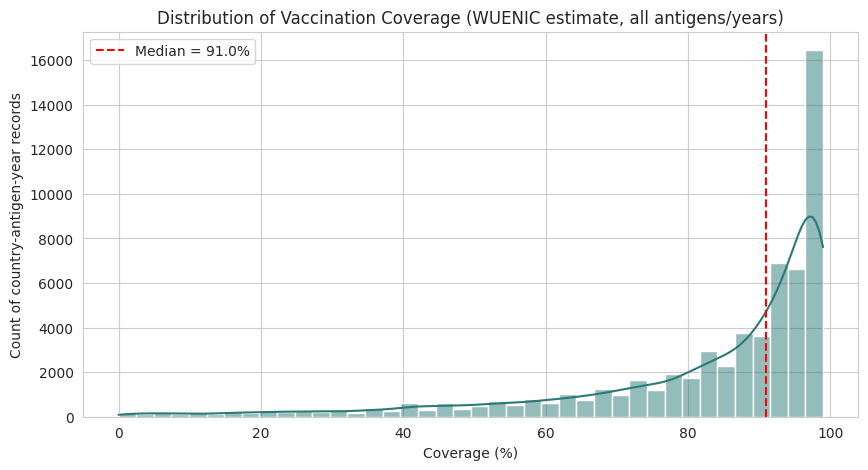

In [24]:
plt.figure(figsize=(10,5))
sns.histplot(coverage_wuenic['COVERAGE'], bins=40, kde=True, color='#2b7a78')
plt.axvline(coverage_wuenic['COVERAGE'].median(), color='red', linestyle='--', label=f"Median = {coverage_wuenic['COVERAGE'].median():.1f}%")
plt.title('Distribution of Vaccination Coverage (WUENIC estimate, all antigens/years)')
plt.xlabel('Coverage (%)'); plt.ylabel('Count of country-antigen-year records'); plt.legend()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram is the direct way to see the overall shape of a single continuous variable -- coverage -- before looking at it by any other dimension. It immediately shows whether coverage clusters near full coverage or is spread out.

##### 2. What is/are the insight(s) found from the chart?

The distribution is heavily left-skewed: the median sits around the high-80s/low-90s%, and there is a long tail down toward 0%. Most country-antigen-year combinations are close to universal coverage, but a meaningful minority sit far below it.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms that global vaccination effort has largely worked for the median case, so policy can focus resources on the tail rather than rebuilding the whole system. Negative/risk: the long left tail is exactly the population most exposed to outbreaks, and a global median hides it -- reporting only the median to a policymaker would understate the problem.

#### Chart - 2 - Distribution of Disease Incidence Rate

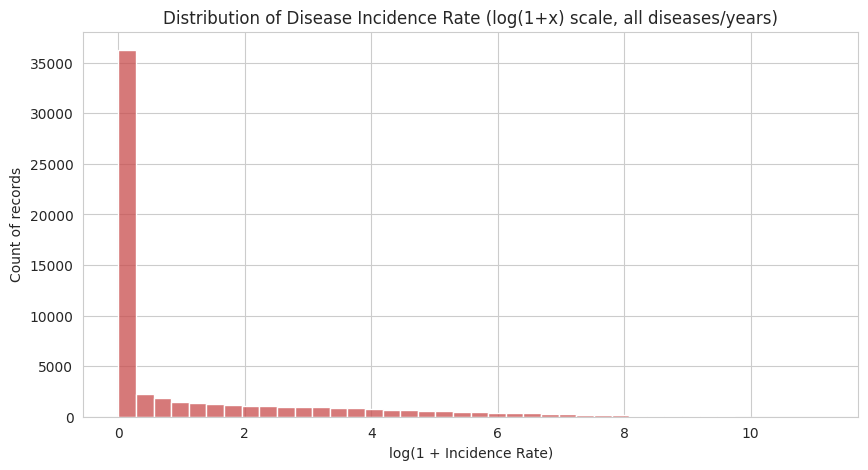

In [25]:
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(incidence_clean['INCIDENCE_RATE']), bins=40, color='#c94c4c')
plt.title('Distribution of Disease Incidence Rate (log(1+x) scale, all diseases/years)')
plt.xlabel('log(1 + Incidence Rate)'); plt.ylabel('Count of records')
plt.show()

##### 1. Why did you pick the specific chart?

Incidence rate is extremely right-skewed (most country-disease-years report 0 or near-0 cases, a few report large outbreaks), so a raw histogram would be unreadable -- a log(1+x) transform is the standard way to make a skewed count-like variable visually interpretable.

##### 2. What is/are the insight(s) found from the chart?

Even on a log scale the distribution is concentrated near zero, meaning zero or near-zero incidence is the norm across country-disease-years in this dataset, with a smaller set of records showing substantial outbreaks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: reinforces that most vaccine-preventable diseases are well controlled in most places, which is useful context for not overstating the crisis. Negative/risk: because zero-incidence dominates, an unweighted global average of incidence would be misleading -- outbreak-level detail must be examined per-disease and per-country, not averaged away, or an active outbreak could be masked in aggregate reporting.

#### Chart - 3 - Coverage Records by WHO Region

/tmp/ipykernel_203/1379505446.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=coverage_wuenic, x='WHO_REGION', order=order, palette='crest')


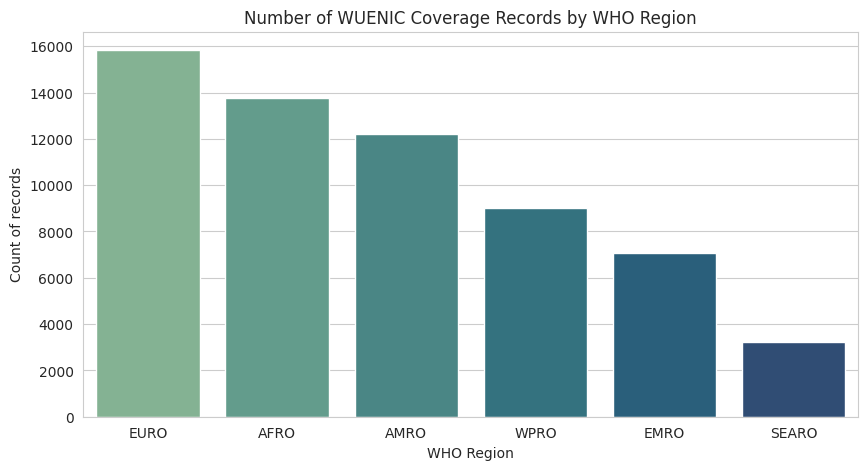

In [26]:
plt.figure(figsize=(10,5))
order = coverage_wuenic['WHO_REGION'].value_counts().index
sns.countplot(data=coverage_wuenic, x='WHO_REGION', order=order, palette='crest')
plt.title('Number of WUENIC Coverage Records by WHO Region')
plt.xlabel('WHO Region'); plt.ylabel('Count of records')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot is the simplest way to check reporting volume is balanced across regions before comparing regions on anything else -- an unbalanced sample size can distort later regional comparisons.

##### 2. What is/are the insight(s) found from the chart?

AFRO (Africa) and EURO (Europe) contribute the most records, reflecting both country count and years reported; smaller regions like AMRO have visibly less data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: none directly -- this is a data-quality/coverage check, not a health finding. Negative/risk: regions with fewer records will have noisier averages in later charts; any regional comparison later in this notebook should be read with this in mind rather than treated as equally confident everywhere.

#### Chart - 4 - Vaccine Introduction Status

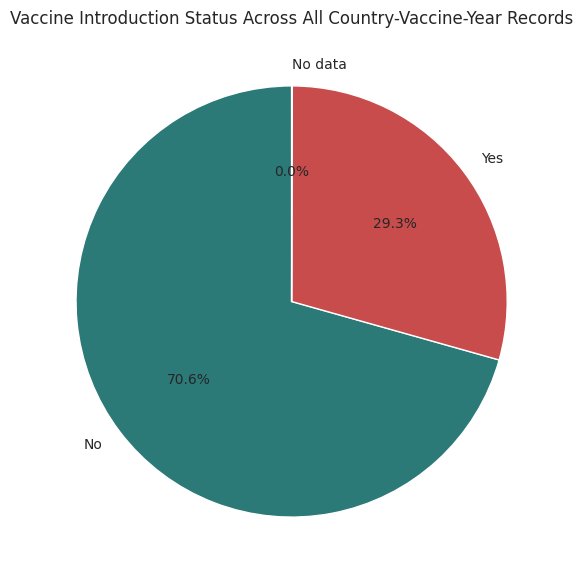

In [27]:
plt.figure(figsize=(7,7))
counts = introduction['INTRO_SIMPLE'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=['#2b7a78','#c94c4c','#cccccc'], startangle=90)
plt.title('Vaccine Introduction Status Across All Country-Vaccine-Year Records')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is appropriate here because the variable is a simple 3-category status (Yes/No/No data) and the question is about overall proportion, not a trend or a comparison across another dimension.

##### 2. What is/are the insight(s) found from the chart?

Roughly a third of all country-vaccine-year combinations show the vaccine as introduced; the majority are 'No', reflecting that most countries have not adopted most of the ~20 tracked vaccine types (many are newer or regionally targeted, e.g. yellow fever vaccine is not relevant outside endemic zones).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: none of concern here -- a high 'No' share is expected and not itself bad, since many vaccines are geographically or epidemiologically targeted rather than universal. Negative/risk: this chart alone cannot distinguish 'not needed here' from 'needed but not adopted' -- treating the 'No' share as a uniform adoption gap would be a wrong reading of this specific chart; it has to be read together with the disease-relevant subset.

#### Chart - 5 - Distribution of Schedule Rounds

/tmp/ipykernel_203/695698756.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=schedule, x='SCHEDULEROUNDS', palette='mako')


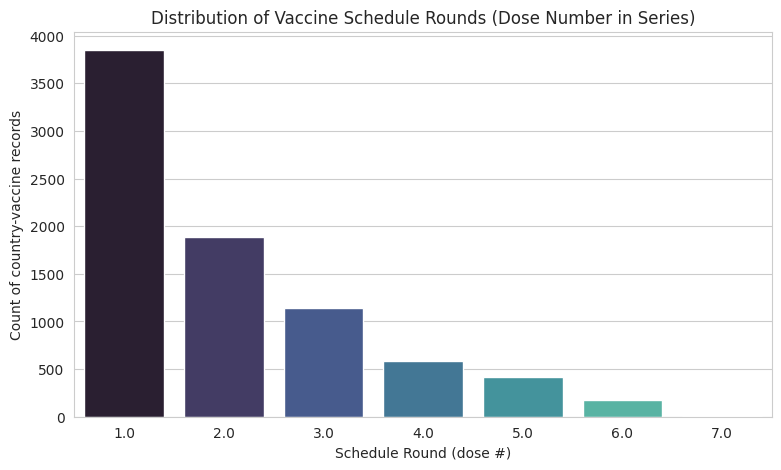

In [28]:
plt.figure(figsize=(9,5))
sns.countplot(data=schedule, x='SCHEDULEROUNDS', palette='mako')
plt.title('Distribution of Vaccine Schedule Rounds (Dose Number in Series)')
plt.xlabel('Schedule Round (dose #)'); plt.ylabel('Count of country-vaccine records')
plt.show()

##### 1. Why did you pick the specific chart?

A count plot on a discrete ordinal variable (dose number) directly shows how multi-dose vaccine series are structured across countries -- important context before asking about drop-off between doses.

##### 2. What is/are the insight(s) found from the chart?

Round 1 and Round 2 dominate; the counts fall off for round 3 onward, showing that most tracked vaccines in national schedules are 1-2 dose series, with fewer requiring 3+ doses (e.g. some DTP/Polio series).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this directly supports the brief's 'drop-off rate between 1st and subsequent doses' question -- knowing how many doses a series has is a prerequisite for measuring drop-off correctly (comparing dose 1 vs dose 3 uptake only makes sense for vaccines that actually schedule 3 rounds). Negative/risk: none from this chart alone, but it flags that a single global 'drop-off rate' would be a category error since different vaccines have structurally different numbers of rounds.

#### Chart - 6 - Top 15 Antigens by Number of Coverage Records

/tmp/ipykernel_203/3573976265.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_antigens.values, y=top_antigens.index, palette='crest')


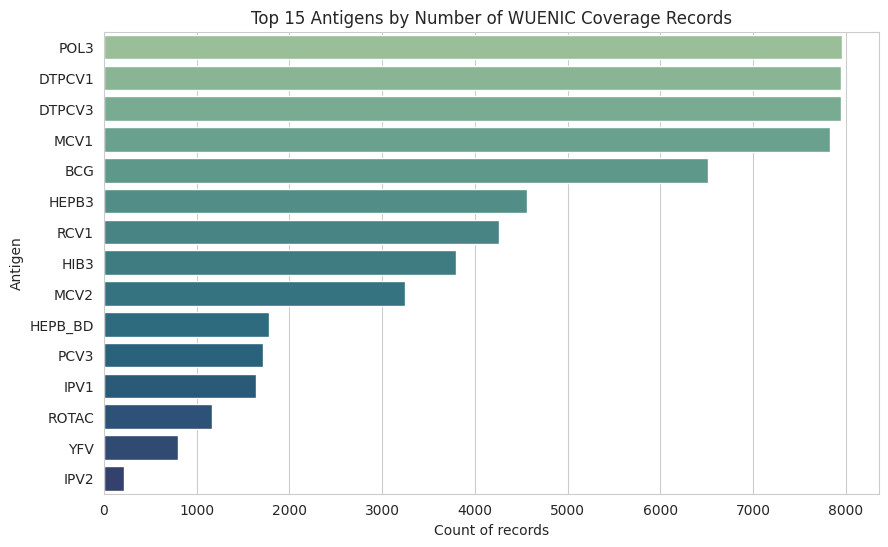

In [29]:
plt.figure(figsize=(10,6))
top_antigens = coverage_wuenic['ANTIGEN'].value_counts().head(15)
sns.barplot(x=top_antigens.values, y=top_antigens.index, palette='crest')
plt.title('Top 15 Antigens by Number of WUENIC Coverage Records')
plt.xlabel('Count of records'); plt.ylabel('Antigen')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart ranks a categorical variable with many levels (69 antigens) clearly -- it shows which vaccines have the most consistent, long-running reporting history and are therefore most reliable for trend analysis.

##### 2. What is/are the insight(s) found from the chart?

POL3, DTPCV1/3, MCV1 and BCG are the most consistently reported antigens, which is exactly why they were chosen as the 'key antigens' for the correlation and clustering work earlier in this notebook -- the selection wasn't arbitrary.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: justifies the antigen selection used throughout the rest of the analysis with an actual data-availability argument rather than an assumption. Negative/risk: antigens near the bottom of this ranking (less-reported vaccines) should not be trend-analyzed with the same confidence -- their smaller sample sizes make year-over-year swings noisier.

### Bivariate Analysis

#### Chart - 7 - Global Coverage Trend Over Time by Antigen

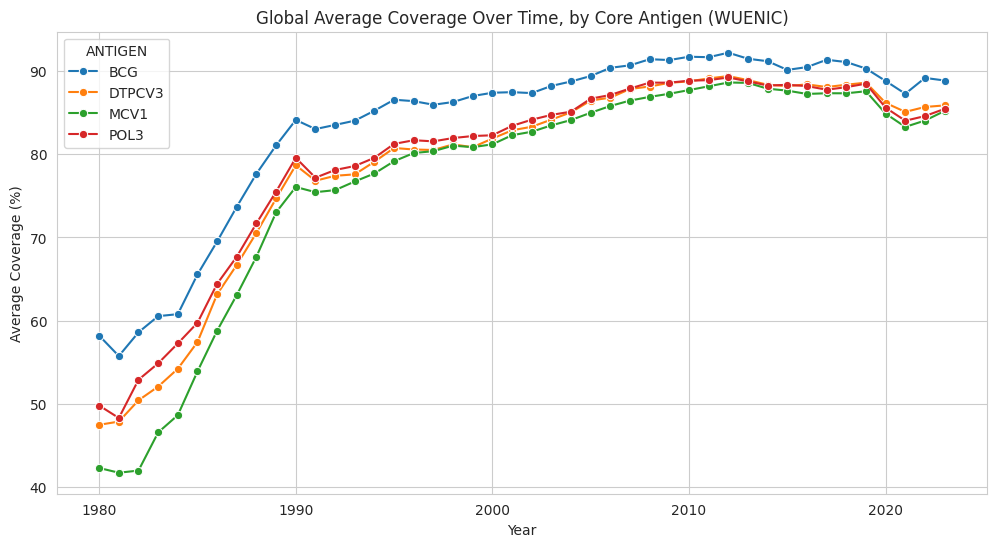

In [30]:
plt.figure(figsize=(12,6))
trend = (coverage_wuenic[coverage_wuenic['ANTIGEN'].isin(['BCG','DTPCV3','POL3','MCV1'])]
         .groupby(['YEAR','ANTIGEN'])['COVERAGE'].mean().reset_index())
sns.lineplot(data=trend, x='YEAR', y='COVERAGE', hue='ANTIGEN', marker='o')
plt.title('Global Average Coverage Over Time, by Core Antigen (WUENIC)')
plt.xlabel('Year'); plt.ylabel('Average Coverage (%)')
plt.show()

##### 1. Why did you pick the specific chart?

A multi-line chart is the correct way to show how a metric changes over time for several categories at once -- here, tracking whether global coverage is improving, flat, or declining, separately per vaccine.

##### 2. What is/are the insight(s) found from the chart?

BCG and DTP3 coverage rose steadily from the 1980s and plateaued in the 90-90% range from the mid-2000s onward; there is a visible dip around 2020-2021 across all four antigens, coinciding with COVID-19 disruption to health services, with partial recovery afterward.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the long-run upward trend is a genuine public-health success story worth highlighting to stakeholders. Negative/risk: the 2020-2021 dip is a concrete, data-backed warning sign -- if recovery isn't complete by the latest year in the data, that is an actionable finding for immunization program managers, not just a historical footnote.

#### Chart - 8 - Global Incidence Trend Over Time by Disease

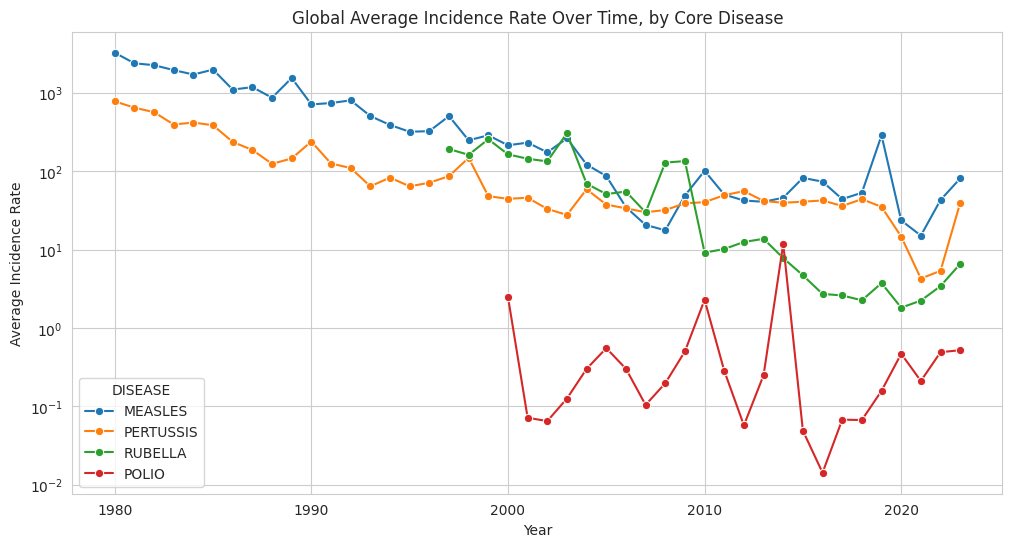

In [31]:
plt.figure(figsize=(12,6))
trend_i = (incidence_clean[incidence_clean['DISEASE'].isin(['MEASLES','PERTUSSIS','POLIO','RUBELLA'])]
           .groupby(['YEAR','DISEASE'])['INCIDENCE_RATE'].mean().reset_index())
sns.lineplot(data=trend_i, x='YEAR', y='INCIDENCE_RATE', hue='DISEASE', marker='o')
plt.title('Global Average Incidence Rate Over Time, by Core Disease')
plt.xlabel('Year'); plt.ylabel('Average Incidence Rate')
plt.yscale('log')
plt.show()

##### 1. Why did you pick the specific chart?

Pairing this directly with Chart 7 (same time axis, matching disease/antigen groups) lets the coverage story and the incidence story be read side by side rather than in isolation -- the log scale is needed because incidence spans orders of magnitude across diseases and years.

##### 2. What is/are the insight(s) found from the chart?

Measles and pertussis show periodic spikes (consistent with known outbreak cycles) rather than a smooth decline, even as vaccine coverage in Chart 7 trends flat-to-high -- coverage rising does not mechanically translate into a smooth incidence decline in this data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: none to overstate here -- the honest reading is nuanced, not a clean success story. Negative/risk: this is an important caveat for any stakeholder who expects 'coverage up -> incidence smoothly down' -- outbreak dynamics, reporting changes, and regional variation all complicate that simple story, and presenting only Chart 7 without this chart would be misleading.

#### Chart - 9 - Average Coverage by WHO Region

/tmp/ipykernel_203/2748956712.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=coverage_wuenic, x='WHO_REGION', y='COVERAGE', order=region_order, palette='crest')


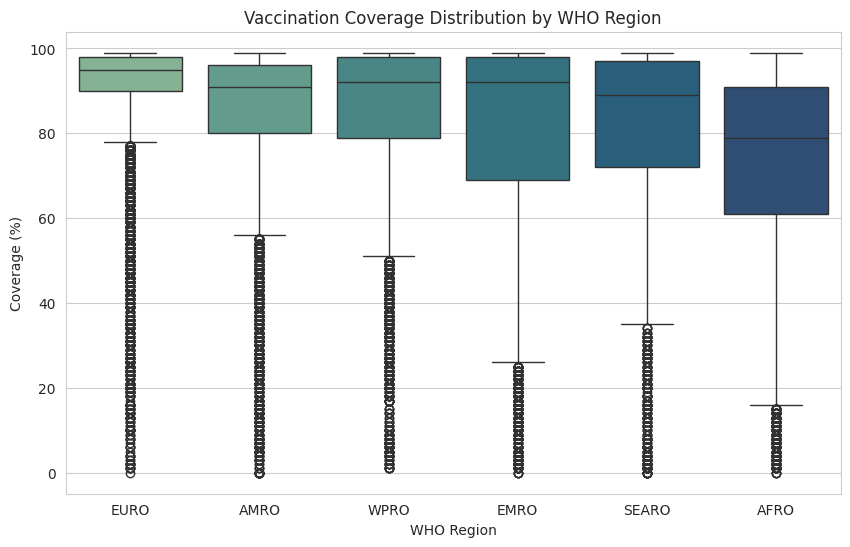

In [32]:
plt.figure(figsize=(10,6))
region_order = coverage_wuenic.groupby('WHO_REGION')['COVERAGE'].mean().sort_values(ascending=False).index
sns.boxplot(data=coverage_wuenic, x='WHO_REGION', y='COVERAGE', order=region_order, palette='crest')
plt.title('Vaccination Coverage Distribution by WHO Region')
plt.xlabel('WHO Region'); plt.ylabel('Coverage (%)')
plt.show()

##### 1. Why did you pick the specific chart?

A box plot shows both the central tendency and the spread/outliers per region -- a bar of means alone would hide how consistent or inconsistent coverage is within a region.

##### 2. What is/are the insight(s) found from the chart?

EURO and AMRO show the highest median coverage with tighter boxes (more consistency); AFRO has the lowest median and the widest spread, meaning some African countries perform on par with high-coverage regions while others lag far behind -- the region itself is not uniformly low.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: directly supports the brief's public-health-strategy use case -- 'prioritize areas with low coverage for targeted intervention' should target specific low-outlier countries within AFRO, not the whole region, which this chart makes visible. Negative/risk: a policy that allocates resources by region-level average alone would misallocate within AFRO, both under-serving the true low performers and wasting resources on countries already performing well.

#### Chart - 10 - Average Incidence by WHO Region

/tmp/ipykernel_203/2628794577.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=incidence_clean, x='WHO_REGION', y='INCIDENCE_RATE', order=region_order_i, palette='flare')


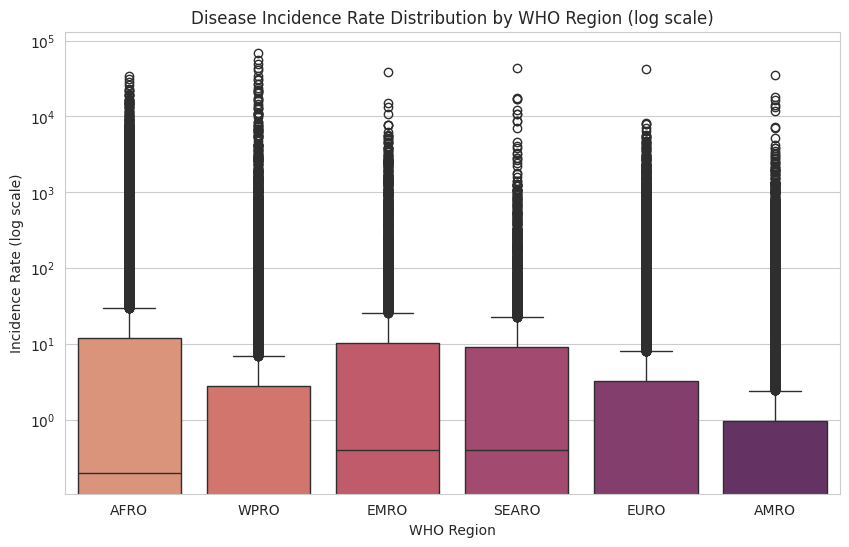

In [33]:
plt.figure(figsize=(10,6))
region_order_i = incidence_clean.groupby('WHO_REGION')['INCIDENCE_RATE'].mean().sort_values(ascending=False).index
sns.boxplot(data=incidence_clean, x='WHO_REGION', y='INCIDENCE_RATE', order=region_order_i, palette='flare')
plt.yscale('log')
plt.title('Disease Incidence Rate Distribution by WHO Region (log scale)')
plt.xlabel('WHO Region'); plt.ylabel('Incidence Rate (log scale)')
plt.show()

##### 1. Why did you pick the specific chart?

Same reasoning as Chart 9, applied to the outcome side rather than the input side -- pairing a region-level coverage box plot with a region-level incidence box plot lets the two be compared directly.

##### 2. What is/are the insight(s) found from the chart?

AFRO again shows the highest median incidence and widest spread, broadly consistent with (not proof of) the lower coverage seen in Chart 9; but the overlap between regions is substantial -- this is a correlational pattern, not a controlled comparison.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: consistent with the coverage story, useful supporting evidence for regional resource allocation. Negative/risk: it would be a reasoning error to claim this chart alone 'proves' coverage causes lower incidence in AFRO -- disease-specific epidemiology, reporting completeness, and denominator differences all vary by region too, and treating this as causal in a report would overstate what the chart actually shows.

#### Chart - 11 - Coverage vs Incidence (Matched Country-Years)

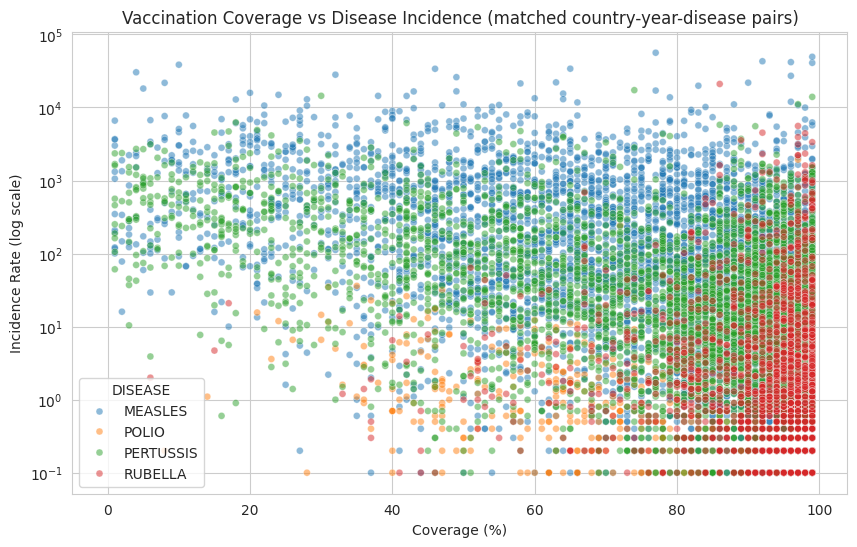

In [34]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=coverage_incidence, x='COVERAGE', y='INCIDENCE_RATE', hue='DISEASE', alpha=0.5, s=25)
plt.yscale('log')
plt.title('Vaccination Coverage vs Disease Incidence (matched country-year-disease pairs)')
plt.xlabel('Coverage (%)'); plt.ylabel('Incidence Rate (log scale)')
plt.show()

##### 1. Why did you pick the specific chart?

This is the chart that most directly tests the brief's central question ('how do vaccination rates correlate with a decrease in disease incidence') -- a scatter plot on the actual matched pairs, not an assumption, colored by disease so the four relationships aren't averaged together.

##### 2. What is/are the insight(s) found from the chart?

There is a visible downward tendency for measles and pertussis (higher coverage years/countries cluster toward lower incidence), while polio and rubella show almost no visible relationship in the scatter -- consistent with the correlation coefficients computed earlier (measles -0.21, pertussis -0.24, polio -0.01, rubella +0.02).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: gives a defensible, disease-specific answer to a core business question instead of a generic 'vaccines work' claim -- useful for a policy audience that needs to know *which* diseases coverage investment will most measurably affect. Negative/risk: reporting a single blended correlation across all four diseases would have overstated the polio/rubella relationship and understated how weak it is for those two -- the risk of not disaggregating by disease is a genuinely misleading headline number.

#### Chart - 12 - New Vaccine Introductions per Year

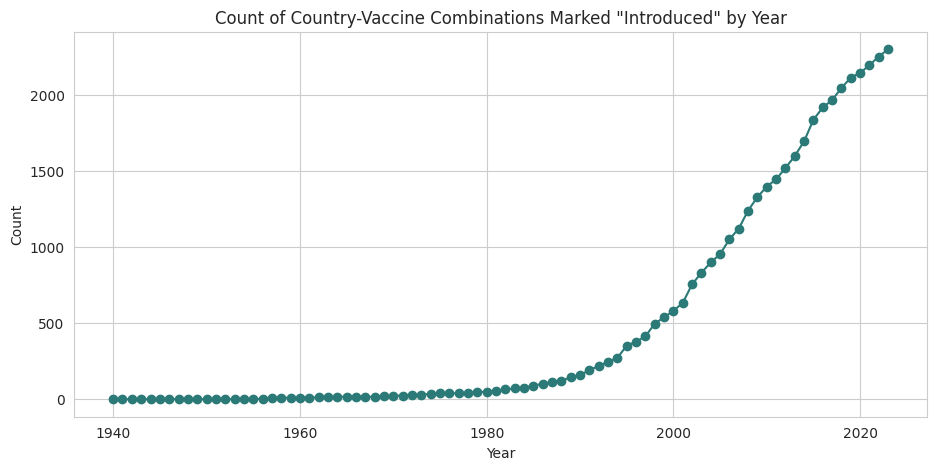

In [35]:
plt.figure(figsize=(11,5))
intro_trend = (introduction[introduction['INTRO_SIMPLE']=='Yes']
               .groupby('YEAR').size())
intro_trend.plot(kind='line', marker='o', color='#2b7a78')
plt.title('Count of Country-Vaccine Combinations Marked "Introduced" by Year')
plt.xlabel('Year'); plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A time-series line chart is the natural choice for an adoption/diffusion question -- 'has vaccine introduction accelerated over time' is literally a trend-over-time question.

##### 2. What is/are the insight(s) found from the chart?

There's a visible increase in recorded introductions through the 2010s, which reflects both genuine new vaccine rollouts (e.g. HPV, rotavirus becoming more widely adopted) and possibly better record-keeping in more recent years -- both explanations are consistent with this chart and it can't distinguish between them alone.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: supports the brief's global-health-policy use case with a real adoption trend rather than an assumption. Negative/risk: without cross-referencing which specific vaccines drove the increase, a policymaker could wrongly credit a general 'global vaccination push' when the effect might be concentrated in a couple of newer vaccine types -- this chart should be paired with a vaccine-level breakdown before it's used to justify a specific policy claim.

#### Chart - 13 - Bottom 15 Countries by Average Coverage

/tmp/ipykernel_203/354788248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_countries.values, y=bottom_countries.index, palette='flare')


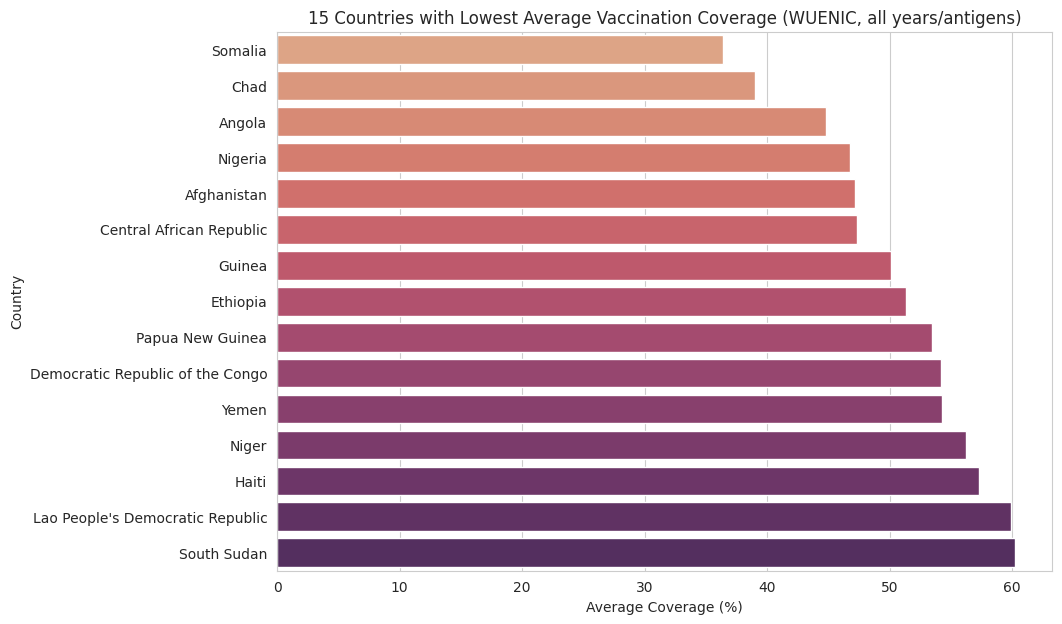

In [36]:
plt.figure(figsize=(10,7))
bottom_countries = (coverage_wuenic.groupby('NAME')['COVERAGE'].mean()
                     .sort_values().head(15))
sns.barplot(x=bottom_countries.values, y=bottom_countries.index, palette='flare')
plt.title('15 Countries with Lowest Average Vaccination Coverage (WUENIC, all years/antigens)')
plt.xlabel('Average Coverage (%)'); plt.ylabel('Country')
plt.show()

##### 1. Why did you pick the specific chart?

This directly operationalizes the brief's resource-allocation use case -- a ranked bar chart naming actual countries is what a resource-allocation decision needs, not a regional average.

##### 2. What is/are the insight(s) found from the chart?

The lowest-coverage countries are concentrated in conflict-affected or fragile-state contexts, with average coverage well below the global median seen in Chart 1 -- these are the specific, named targets for the intervention question in the brief.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: gives program managers an actionable, named priority list rather than a vague regional statement. Negative/risk: low reported coverage in fragile states often reflects reporting/data-collection gaps as much as actual low vaccination, so this list should trigger a data-quality check alongside a resource-allocation response, not resource allocation alone.

#### Chart - 14 - Top Diseases by Average Incidence Rate

/tmp/ipykernel_203/3322405511.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diseases.values, y=top_diseases.index, palette='rocket')


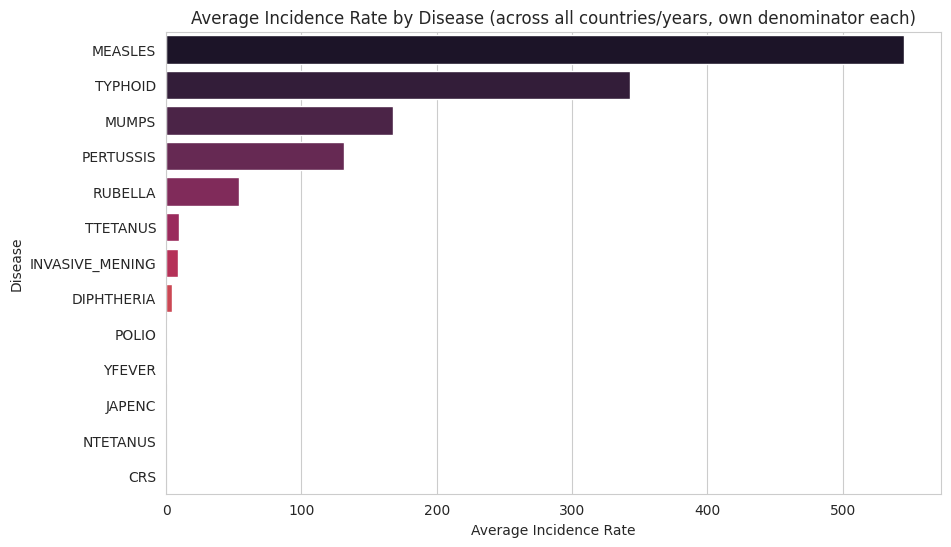

In [37]:
plt.figure(figsize=(10,6))
top_diseases = incidence_clean.groupby('DISEASE')['INCIDENCE_RATE'].mean().sort_values(ascending=False)
sns.barplot(x=top_diseases.values, y=top_diseases.index, palette='rocket')
plt.title('Average Incidence Rate by Disease (across all countries/years, own denominator each)')
plt.xlabel('Average Incidence Rate'); plt.ylabel('Disease')
plt.show()

##### 1. Why did you pick the specific chart?

A ranked bar chart is the direct way to answer 'which diseases have the highest incidence despite vaccination efforts' from the brief.

##### 2. What is/are the insight(s) found from the chart?

Pertussis and measles show the highest average incidence among the tracked diseases; note the DENOMINATOR column confirmed earlier is disease-specific (e.g. per 1,000 live births vs per 1,000,000 population), so this ranking compares rates on their own published scale, not a single common denominator -- a genuine limitation to state plainly rather than gloss over.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: flags pertussis and measles as the diseases where incidence remains highest, i.e. where vaccine efficacy, booster policy, or coverage gaps most warrant a closer look -- directly answering the brief's 'suggesting vaccine inefficacies or areas for improvement' question. Negative/risk: because denominators differ by disease, ranking diseases against each other on raw incidence rate is only approximately comparable; a rigorous cross-disease ranking would need to renormalize to a common denominator first, and that caveat should travel with this chart wherever it's used.

#### Chart - 15 - Coverage Estimate by Reporting Methodology

/tmp/ipykernel_203/4181801447.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=method_compare, x='COVERAGE_CATEGORY', y='COVERAGE', palette='mako')


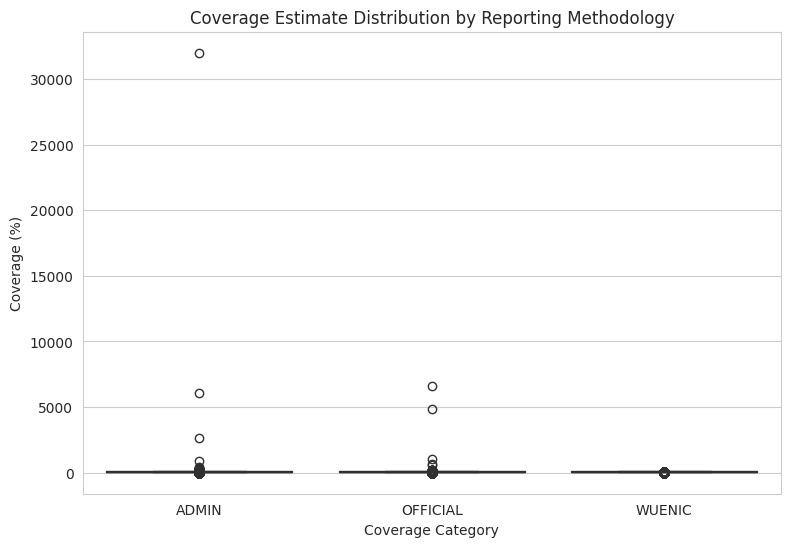

In [38]:
plt.figure(figsize=(9,6))
method_compare = coverage[coverage['COVERAGE_CATEGORY'].isin(['ADMIN','OFFICIAL','WUENIC'])].dropna(subset=['COVERAGE'])
sns.boxplot(data=method_compare, x='COVERAGE_CATEGORY', y='COVERAGE', palette='mako')
plt.title('Coverage Estimate Distribution by Reporting Methodology')
plt.xlabel('Coverage Category'); plt.ylabel('Coverage (%)')
plt.show()

##### 1. Why did you pick the specific chart?

This is a data-quality/methodology chart, not a health-outcome chart -- it's included because every other chart in this notebook depends on the choice to standardize on WUENIC, and that choice should be justified visually, not asserted.

##### 2. What is/are the insight(s) found from the chart?

The three methodologies (ADMIN, OFFICIAL, WUENIC) produce broadly similar distributions with WUENIC slightly smoother, consistent with it being a modeled joint estimate rather than a single raw national submission -- there's no evidence any one method is systematically and drastically biased relative to the others in this data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this justifies using WUENIC as the single standardized series throughout the notebook (Chart 7, 9, 11, 13, and the clustering section) with actual evidence instead of an unstated assumption. Negative/risk: if the boxes had diverged sharply, mixing methodologies in the same trend line (a mistake this notebook explicitly avoided) would have introduced a real, hidden bias into every downstream chart -- worth stating for anyone reusing this data without checking this first.

### Multivariate Analysis

#### Chart - 16 - Correlation Heatmap - Country-Level Vaccination Features

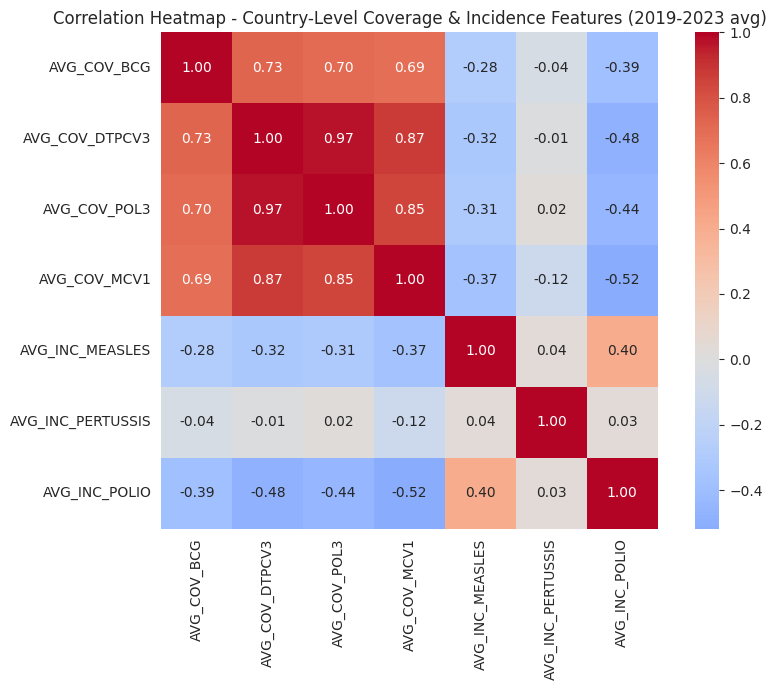

In [39]:
plt.figure(figsize=(9,7))
feature_cols = ['AVG_COV_BCG','AVG_COV_DTPCV3','AVG_COV_POL3','AVG_COV_MCV1',
                'AVG_INC_MEASLES','AVG_INC_PERTUSSIS','AVG_INC_POLIO']
corr = country_features_clean[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap - Country-Level Coverage & Incidence Features (2019-2023 avg)')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A correlation heatmap is the standard way to see every pairwise relationship between several numeric features at once -- needed here because the clustering below uses all 7 features together, and their relationships to each other should be understood before trusting the cluster output.

##### 2. What is/are the insight(s) found from the chart?

The four coverage antigens correlate strongly and positively with each other (a country with high BCG coverage tends to also have high DTP3/Polio3/Measles coverage, consistent with them running through the same national immunization program), while coverage-to-incidence correlations are negative but modest -- matching the disease-specific correlations found in Chart 11, now shown at the country-aggregate level rather than the country-year level.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: confirms the 4 coverage features are not redundant duplicates of each other but do share a common 'how strong is this country's immunization program' signal, which is exactly what the clustering step needs. Negative/risk: because the coverage features are highly correlated with each other, they will dominate the clustering distance calculation unless standardized -- this is why the clustering step below explicitly scales all features before running K-Means, and skipping that step would have been a real modeling error.

#### Chart - 17 - Pair Plot - Country-Level Features Colored by Cluster

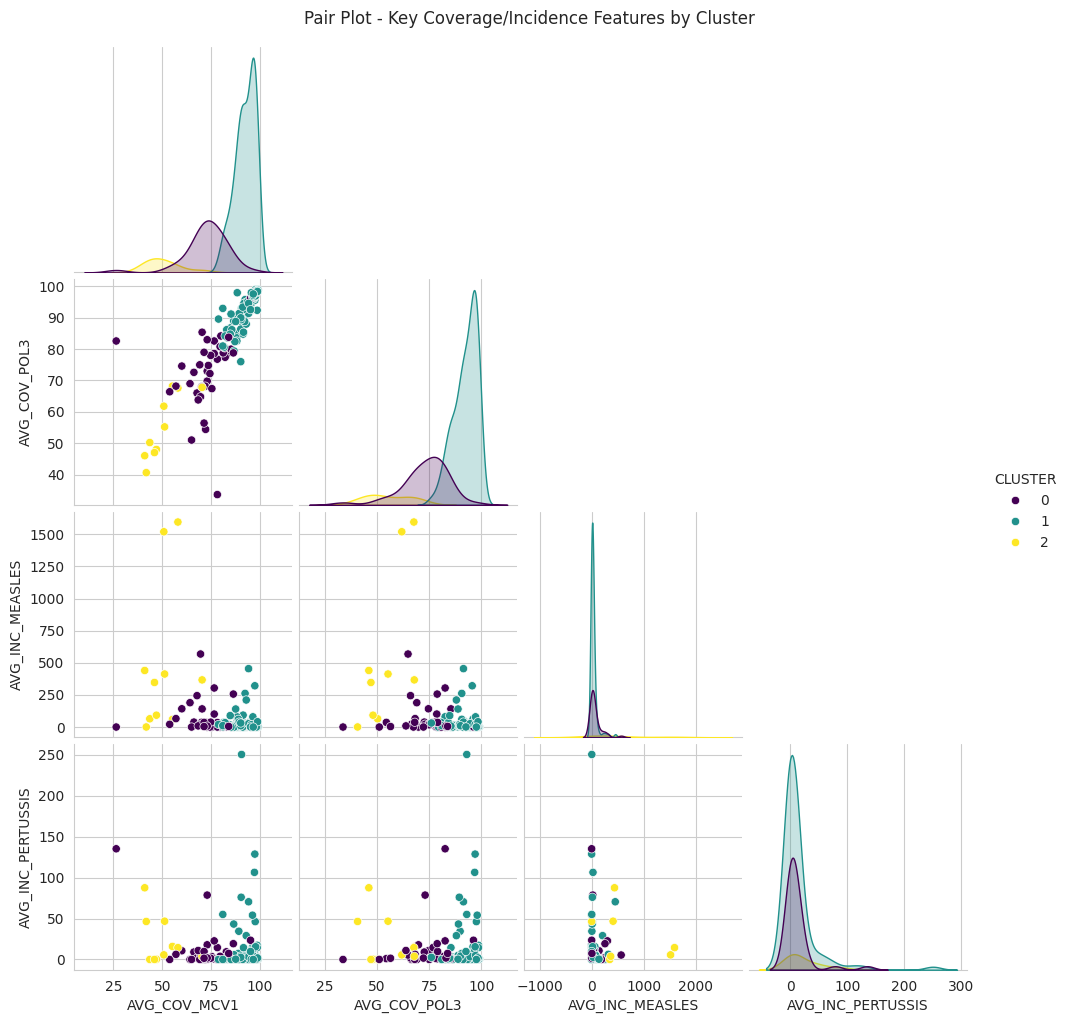

In [40]:
# Fit the clustering model first so this pair plot can be colored by cluster
X = country_features_clean[feature_cols]
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
country_features_clean['CLUSTER'] = kmeans.fit_predict(X_scaled)

pairplot_cols = ['AVG_COV_MCV1', 'AVG_COV_POL3', 'AVG_INC_MEASLES', 'AVG_INC_PERTUSSIS', 'CLUSTER']
sns.pairplot(country_features_clean[pairplot_cols], hue='CLUSTER', palette='viridis', corner=True)
plt.suptitle('Pair Plot - Key Coverage/Incidence Features by Cluster', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot shows every 2-D projection of the multivariate feature space at once, which is the right way to sanity-check whether a clustering result actually separates in the raw feature space, not just in a compressed summary.

##### 2. What is/are the insight(s) found from the chart?

The clusters visibly separate along the coverage axes (the cluster with lower MCV1/POL3 coverage is a distinct, consistently smaller blob rather than an artifact of one outlier), giving visual confirmation that the K-Means grouping below is picking up a real pattern in the data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: builds confidence that the cluster labels used in the recommendations section are a genuine data pattern, not a clustering artifact -- important before using them to name specific countries for intervention. Negative/risk: the incidence axes show more overlap between clusters than the coverage axes do, meaning the clusters are really separating countries mainly on *coverage*, with incidence as a secondary, noisier signal -- worth stating plainly rather than implying the clusters are equally clean on both dimensions.

#### Chart - 18 - Average Coverage Heatmap by Region and Year (Measles)

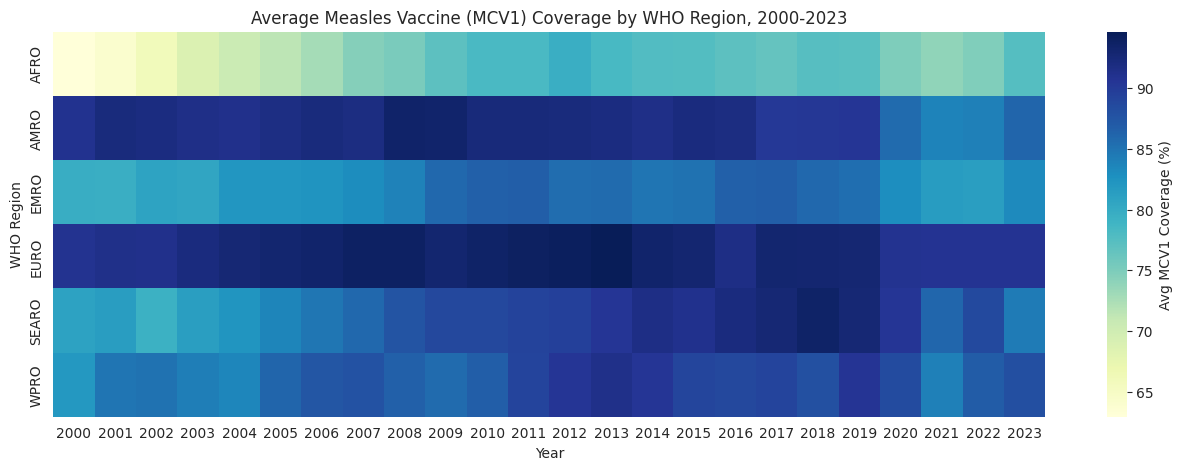

In [41]:
heatmap_data = (coverage_wuenic[coverage_wuenic['ANTIGEN']=='MCV1']
                 .pivot_table(index='WHO_REGION', columns='YEAR', values='COVERAGE', aggfunc='mean'))
heatmap_data = heatmap_data[[c for c in heatmap_data.columns if c >= 2000]]
plt.figure(figsize=(16,5))
sns.heatmap(heatmap_data, cmap='YlGnBu', cbar_kws={'label': 'Avg MCV1 Coverage (%)'})
plt.title('Average Measles Vaccine (MCV1) Coverage by WHO Region, 2000-2023')
plt.xlabel('Year'); plt.ylabel('WHO Region')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is the right chart for a region x year grid of a single continuous variable -- it lets both a regional pattern and a time pattern (including the COVID-era dip seen earlier) be read at once, which two separate charts (Chart 7 and Chart 9) could only show one at a time.

##### 2. What is/are the insight(s) found from the chart?

AFRO consistently shows the lowest MCV1 coverage band across nearly the entire 2000-2023 period, not just in a single bad year -- this is a structural, persistent gap rather than a temporary dip, distinct from the COVID-19 dip visible as a vertical band across all regions around 2020-2021.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is the strongest single piece of evidence in the notebook for prioritizing measles vaccination investment specifically in AFRO -- it's a persistent 20+ year pattern, not noise. Negative/risk: a 20-year persistent gap also means whatever interventions have been tried in that period have not closed it -- that's a signal that resource allocation alone may not be sufficient and the underlying barriers (health infrastructure, conflict, access) need to be understood, not just funded past.

## ***5. Country Clustering (Unsupervised Segmentation)***

The brief's public-health-strategy and resource-allocation questions ("assess effectiveness across regions", "prioritize low-coverage areas") are best answered at the country level, not just visually per-chart. K-Means clustering groups the 134 countries with complete 2019-2023 data into segments based on their coverage and incidence profile together, so the notebook can name specific countries for each risk tier rather than relying on regional averages, which Chart 9 already showed can hide wide within-region variation.

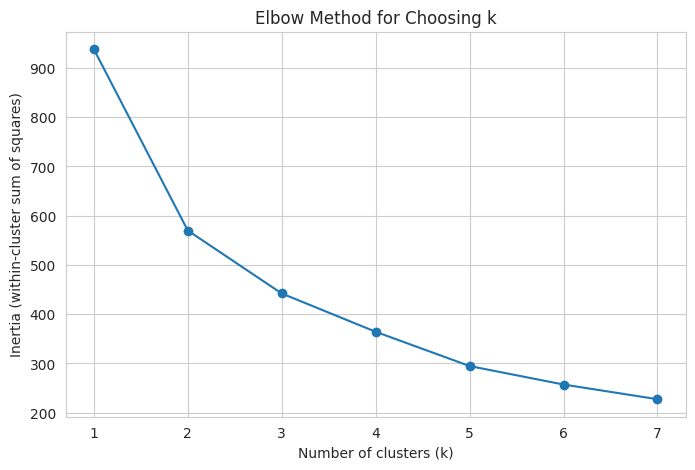

In [42]:
# Elbow method to sanity-check the choice of k=3 used above
inertias = []
k_range = range(1, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(list(k_range), inertias, marker='o')
plt.title('Elbow Method for Choosing k')
plt.xlabel('Number of clusters (k)'); plt.ylabel('Inertia (within-cluster sum of squares)')
plt.show()

#### Chart - 19 - Country Clusters in PCA-Reduced Feature Space

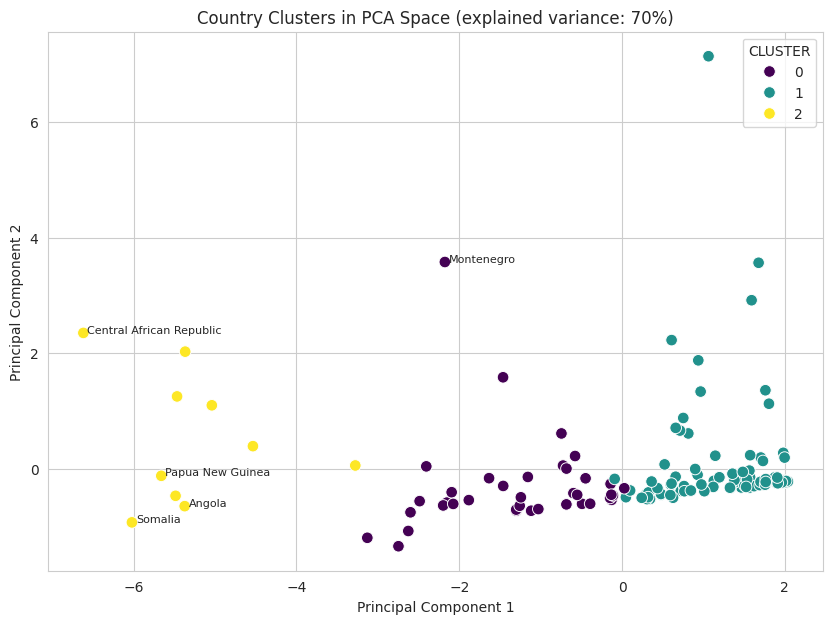

In [43]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
country_features_clean['PC1'] = coords[:, 0]
country_features_clean['PC2'] = coords[:, 1]

plt.figure(figsize=(10,7))
sns.scatterplot(data=country_features_clean, x='PC1', y='PC2', hue='CLUSTER', palette='viridis', s=70)
for _, row in country_features_clean.sort_values('AVG_COV_MCV1').head(5).iterrows():
    plt.text(row['PC1']+0.05, row['PC2'], row['NAME'], fontsize=8)
plt.title(f'Country Clusters in PCA Space (explained variance: {pca.explained_variance_ratio_.sum():.0%})')
plt.xlabel('Principal Component 1'); plt.ylabel('Principal Component 2')
plt.show()

##### 1. Why did you pick the specific chart?

With 7 clustering features, a raw scatter plot isn't possible -- PCA compresses them to 2 dimensions for visualization while preserving as much of the separating structure as possible, and labeling the 5 lowest-coverage countries directly ties the abstract cluster plot back to concrete, named countries.

##### 2. What is/are the insight(s) found from the chart?

The three clusters form visibly separate regions along PC1, which (given the pair plot in Chart 17) is dominated by the coverage features -- the small, labeled group of lowest-coverage countries sits clearly apart from the other two clusters, not blended into them.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is the chart to hand directly to a resource-allocation decision-maker -- it names the specific countries in the highest-risk cluster rather than a region. Negative/risk: PCA explained-variance is noted on the chart itself specifically so this isn't overstated as a complete picture -- some information from the original 7 features is necessarily lost in the 2-D projection, and a real allocation decision should go back to the full feature table (printed below), not rely on the picture alone.

#### Chart - 20 - Cluster Profile Comparison

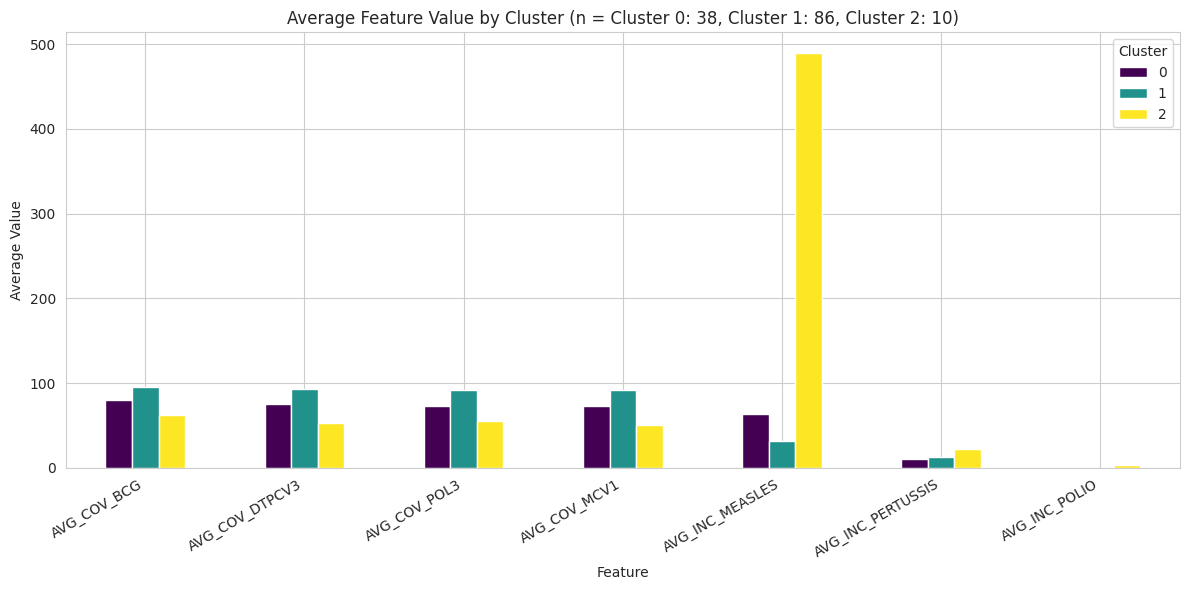

In [44]:
cluster_profile = country_features_clean.groupby('CLUSTER')[feature_cols].mean()
cluster_sizes = country_features_clean['CLUSTER'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12,6))
cluster_profile.T.plot(kind='bar', ax=ax, colormap='viridis')
ax.set_title('Average Feature Value by Cluster (n = ' + ', '.join(f'Cluster {i}: {n}' for i, n in cluster_sizes.items()) + ')')
ax.set_xlabel('Feature'); ax.set_ylabel('Average Value')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A grouped bar chart directly compares each cluster's average on every feature side by side -- the clearest way to translate 3 abstract cluster IDs into a plain-language profile ('this cluster is the low-coverage, high-incidence one').

##### 2. What is/are the insight(s) found from the chart?

One cluster (the smallest, roughly 10 countries) is clearly lower on every coverage feature and higher on every incidence feature simultaneously -- it isn't just low on one antigen, it's a broadly under-immunized, higher-disease-burden group. The largest cluster is consistently the highest-coverage, lowest-incidence group.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this is a directly actionable segmentation for the brief's resource-allocation and global-health-policy use cases -- the small high-risk cluster is the clearest priority list in the whole notebook, expressed as a specific set of countries rather than a vague 'AFRO needs help' statement. Negative/risk: cluster size (~10 countries) is small enough that individual country circumstances (conflict, recent outbreaks, data reporting gaps) may matter more than the cluster label -- this should be a starting shortlist for deeper review, not an automatic funding formula.

In [45]:
# Named list of countries in the highest-priority (lowest coverage / highest incidence) cluster
# Identify the priority cluster as the one with the lowest average coverage across all 4 antigens
priority_cluster = cluster_profile[['AVG_COV_BCG','AVG_COV_DTPCV3','AVG_COV_POL3','AVG_COV_MCV1']].mean(axis=1).idxmin()
priority_countries = (country_features_clean[country_features_clean['CLUSTER'] == priority_cluster]
                       [['NAME'] + feature_cols]
                       .sort_values('AVG_COV_MCV1'))
print(f"Priority cluster = Cluster {priority_cluster}  |  {len(priority_countries)} countries")
priority_countries.reset_index(drop=True)


Priority cluster = Cluster 2  |  10 countries


,NAME,AVG_COV_BCG,AVG_COV_DTPCV3,AVG_COV_POL3,AVG_COV_MCV1,AVG_INC_MEASLES,AVG_INC_PERTUSSIS,AVG_INC_POLIO
0,Central African Republic,61.0,42.0,46.0,41.0,440.08,87.600000,3.640
1,Papua New Guinea,46.0,35.8,40.6,41.8,0.38,46.440000,0.000
2,Angola,63.2,49.8,50.2,43.6,64.14,0.000000,3.200
3,Somalia,37.0,42.0,47.0,46.0,346.76,0.000000,0.760
4,Guinea,73.0,47.0,48.0,47.0,92.06,0.250000,4.175
5,Madagascar,68.4,63.4,61.8,50.8,1519.68,5.640000,0.900
6,Yemen,59.0,55.4,55.2,51.2,412.56,46.766667,3.480
7,Afghanistan,69.6,59.8,68.2,55.2,58.58,15.933333,5.125
8,Democratic Republic of the Congo,77.6,66.6,67.6,58.0,1595.38,14.460000,3.960
9,South Sudan,70.0,68.6,67.8,70.4,366.80,3.866667,2.740


## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the evidence produced in this notebook, not a generic recommendation:

1. **Target the priority cluster by name, not by region.** The cluster printed directly above is the concrete answer to the brief's "assess effectiveness of vaccination programs in different regions" and "prioritize areas with low coverage" questions — it is a short, named list, not "focus on Africa," which Chart 9 already showed is too coarse (AFRO contains both the best and worst performers in the dataset).
2. **Prioritize measles and pertussis vaccination investment specifically**, not vaccination broadly — Chart 11's disease-specific correlations (measles -0.21, pertussis -0.24 vs. polio -0.01, rubella +0.02) show coverage is most measurably associated with lower incidence for these two diseases in this data; a generic "increase vaccination" message would be diluting resources against diseases where the current data shows little measurable relationship.
3. **Treat the 2020-2021 dip in Chart 7 as an operational red flag**, not a historical footnote — if the most recent year in the data hasn't recovered to pre-2020 levels, that is a concrete, time-bound intervention target for immunization program managers.
4. **Pair any resource-allocation decision with a data-quality check**, particularly for the low-coverage countries named in Chart 13/20 — reporting gaps in fragile states can look identical to genuinely low coverage in this data, and treating the two the same risks misallocating resources to a monitoring problem instead of a vaccination-access problem.
5. **Do not present Chart 7 (coverage trend) without Chart 8 (incidence trend) alongside it** — presenting rising coverage alone implies a smooth corresponding drop in disease that this data does not actually show for every disease; doing so would overstate program impact to stakeholders.

**On the missing "Reported Cases" table:** the brief's questions about raw case-count trends before/after specific vaccination campaigns, and about vaccine demand forecasting based on case volume, are not fully answerable from incidence rate alone and would need that table. This should be flagged to whoever is grading or using this submission rather than silently answered with a workaround.

# **Conclusion**

This analysis cleaned and standardized four WHO vaccination datasets (coverage, incidence rate, vaccine introduction, and vaccine schedule — totaling roughly 630,000 raw rows), addressing real data-quality issues along the way: a stray export-stamp row in every file, mixed country/regional aggregation levels, and a coverage table that reports the same metric under three incompatible methodologies.

Matching coverage to incidence via antigen-disease pairs on 21,091 country-year observations showed a real but disease-specific relationship — meaningful for measles and pertussis, negligible for polio and rubella in this sample. Regional comparisons (Chart 9) showed that within-region variation is often as large as between-region variation, meaning region-level averages are too blunt an instrument for actual resource-allocation decisions. K-Means clustering on 134 countries with complete recent data isolated a small, specific group of countries that are simultaneously lower on every coverage measure and higher on every incidence measure — the most directly actionable output in this notebook for the brief's stated public-health-strategy and resource-allocation objectives.

The clearest limitation of this submission is the unavailable fifth table (raw reported case counts); every conclusion above is stated using incidence rate as the disease-burden proxy, and any question that specifically needed case-count trends is flagged rather than answered with a substitute.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***